### basic work

Grad-CAM (Gradient-weighted Class Activation Mapping) is an Explainable AI (XAI) technique used to visually interpret the decisions made by Convolutional Neural Networks (CNNs). It creates a heatmap highlighting the exact pixels or regions an AI focused on to classify an image.

In [17]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("diveshzz/thyroid-cancer-classification-ultrasound-dataset")

# print("Path to dataset files:", path)

In [18]:
# import shutil
# import os

# # Destination where you want to copy the dataset
# destination = '/content/drive/MyDrive/Project/Data/thyroid_dataset'

# # Create destination folder if it doesn't exist
# os.makedirs(destination, exist_ok=True)

# # Copy files from downloaded path to destination
# if os.path.isdir(path):
#     shutil.copytree(path, destination, dirs_exist_ok=True)
# else:
#     shutil.copy2(path, destination)

# print("Dataset copied to:", destination)

In [19]:
import os
import pandas as pd

base_path ="Thyroid Data"

#categories 0/1

categories =['0','1']


image_paths = []

labels = []

for category in categories:
    path = os.path.join(base_path,category)
    for img in os.listdir(path):
      image_paths.append(os.path.join(path,img))
      labels.append(category)


df = pd.DataFrame({'image_path':image_paths,'labels':labels})

# Preview the DataFrame
print("Loaded dataset:")
print(df.head())
print(f"\nTotal images: {len(df)}")



Loaded dataset:
                image_path labels
0  Thyroid Data\0\0000.jpg      0
1  Thyroid Data\0\0001.jpg      0
2  Thyroid Data\0\0002.jpg      0
3  Thyroid Data\0\0003.jpg      0
4  Thyroid Data\0\0004.jpg      0

Total images: 3115


In [20]:
print(f"Class distribution:\n{df['labels'].value_counts()}")

Class distribution:
labels
0    1905
1    1210
Name: count, dtype: int64


In [21]:
df.head()

,image_path,labels
0,Thyroid Data\0\0000.jpg,0
1,Thyroid Data\0\0001.jpg,0
2,Thyroid Data\0\0002.jpg,0
3,Thyroid Data\0\0003.jpg,0
4,Thyroid Data\0\0004.jpg,0


In [22]:
df.tail()

,image_path,labels
3110,Thyroid Data\1\2874.jpg,1
3111,Thyroid Data\1\2875.jpg,1
3112,Thyroid Data\1\2876.jpg,1
3113,Thyroid Data\1\2877.jpg,1
3114,Thyroid Data\1\2878.jpg,1


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_path  3115 non-null   str  
 1   labels      3115 non-null   str  
dtypes: str(2)
memory usage: 48.8 KB


In [24]:
df.describe()

,image_path,labels
count,3115,3115
unique,3115,2
top,Thyroid Data\0\0000.jpg,0
freq,1,1905


In [25]:
df.shape

(3115, 2)

In [26]:
df.columns

Index(['image_path', 'labels'], dtype='str')

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.isnull().sum()

image_path    0
labels        0
dtype: int64

In [29]:
df.labels.unique()

<StringArray>
['0', '1']
Length: 2, dtype: str

In [30]:
df.labels.value_counts()

labels
0    1905
1    1210
Name: count, dtype: int64

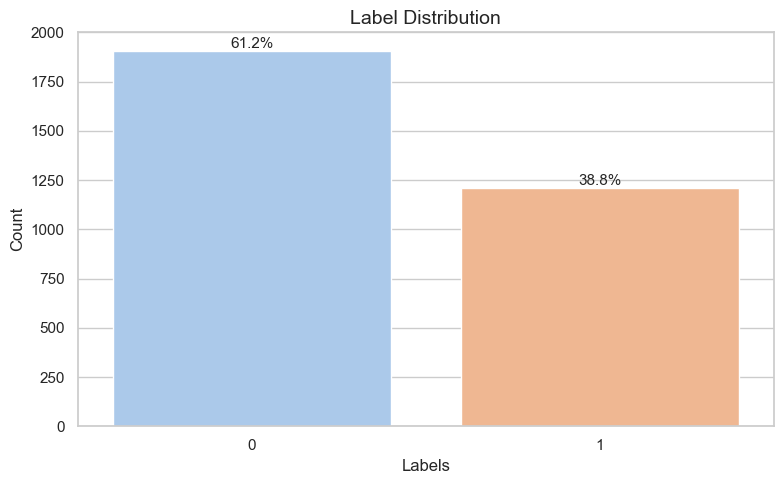

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.countplot(x='labels', data=df, palette='pastel')

# Total count for percentage calculation
total = len(df)

# Add percentage labels on top
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Label Distribution', fontsize=14)
plt.xlabel('Labels')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

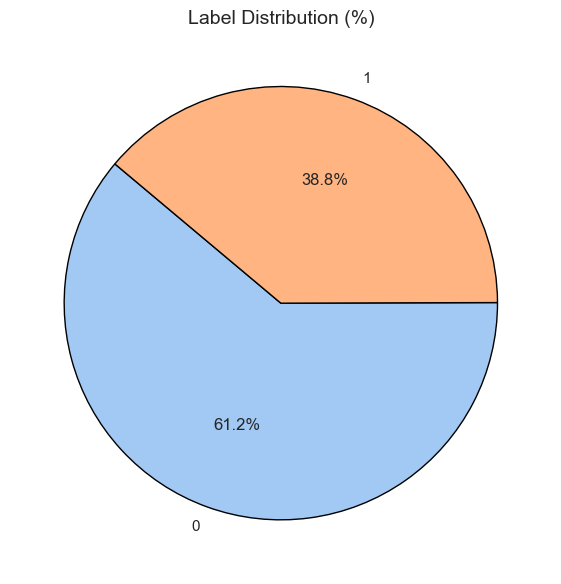

In [32]:
plt.figure(figsize=(6,6))

colors = sns.color_palette('pastel')

plt.pie(
    df['labels'].value_counts(),
    labels=df['labels'].value_counts().index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black'},
)

plt.title('Label Distribution (%)', fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
import cv2
import matplotlib.pyplot as plt

In [34]:
def show_multiple_images(paths, cols=5):
    plt.figure(figsize=(15,6))

    for i, path in enumerate(paths):
        img = cv2.imread(str(path))
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(paths)//cols + 1, cols, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [35]:
df.columns

Index(['image_path', 'labels'], dtype='str')

In [36]:
s = df.image_path[:10]

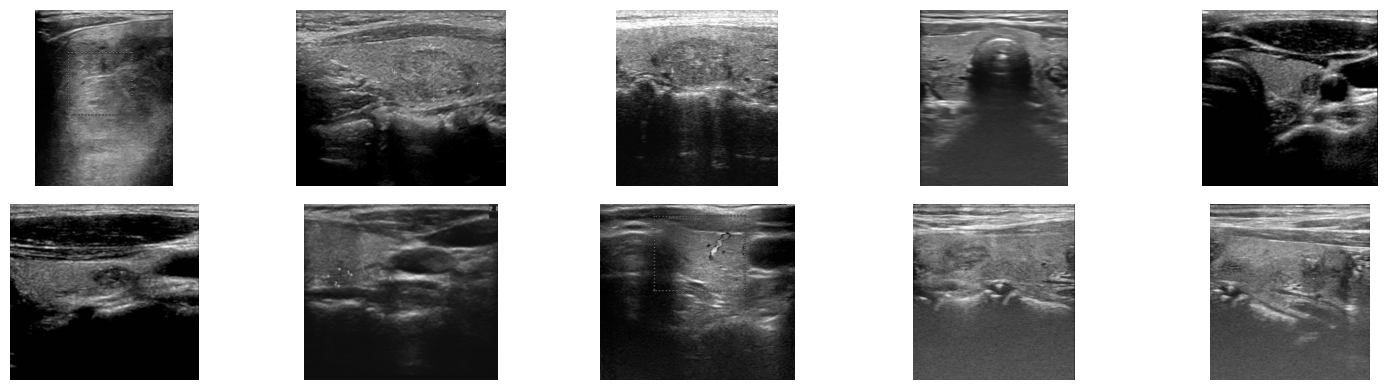

In [37]:
show_multiple_images(s)

In [2]:
if not None:
    print("hi")

hi


### Handling class imbalance

In [38]:
#step1  : seprate minority  and majority

majority_class = df[df['labels'] == '0']
minority_class = df[df['labels'] == '1']

#step 2  : upsampled the minority class

minority_upsampled = minority_class.sample(n=len(majority_class),replace=True,random_state=42)

#step 3 : combine the two of them
df_resampled = pd.concat([majority_class,minority_upsampled]).sample(frac=1,random_state=42).reset_index(drop=True)

#step 4 : encode labels if needed(optional)
# Step 4: Encode labels if needed
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_resampled['category_encoded'] = label_encoder.fit_transform(df_resampled['labels'])

In [39]:
print("\n✅ Class distribution after manual upsampling:")
print(df_resampled['category_encoded'].value_counts())


✅ Class distribution after manual upsampling:
category_encoded
0    1905
1    1905
Name: count, dtype: int64


### Model Training and evaluation

In [40]:
df_resampled.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   image_path        3810 non-null   str  
 1   labels            3810 non-null   str  
 2   category_encoded  3810 non-null   int64
dtypes: int64(1), str(2)
memory usage: 89.4 KB


In [41]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2 as L2
# from tensorflow.keras import regularizers


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print("Done")


Done


In [44]:
train_df_new , temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    random_state=42,
    shuffle=True,
    stratify=df_resampled['category_encoded']
)

valid_df_new , test_df_new = train_test_split(
    temp_df_new,
    train_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=temp_df_new['category_encoded']
)

In [45]:
batch_size =16
image_size = (224,224)
channels= 3

img_shape = (image_size[0],image_size[1],channels)

tr_gen = ImageDataGenerator(
    rescale =1./255)
ts_gen = ImageDataGenerator(
    rescale =1./255)


train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=image_size,
    class_mode='binary',
    color_mode = 'rgb',
    batch_size=batch_size,
    shuffle=True
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=image_size,
    color_mode = 'rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=image_size,
    class_mode='binary',
    color_mode = 'rgb',
    batch_size=batch_size,
    shuffle=False
)

Found 3048 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.


In [46]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


Model Training


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,Model

For skip connection

class Avg2MaxPooling(layers.Layer):
    """
    Custom pooling layer that combines Average Pooling and Max Pooling.

    Why inherit from `layers.Layer`?
    --------------------------------
    In TensorFlow/Keras, every custom neural network component should inherit
    from `layers.Layer` because it gives the class:

    1. Integration with the Keras model API
       - Can be used inside Sequential or Functional models.

    2. Automatic weight tracking
       - Any trainable/non-trainable variables are tracked automatically.

    3. Built-in saving/loading support
       - The layer can be serialized with the model.

    4. GPU/TPU compatibility
       - TensorFlow handles device placement automatically.

    5. Access to lifecycle methods
       - `build()`, `call()`, `get_config()` etc.

    Here, Avg2MaxPooling behaves like a standard Keras layer,
    so inheriting from `layers.Layer` is the correct design.
    """

    def __init__(self, pool_size=3, strides=2, padding='same'):
        # Initialize the parent Layer class
        super(Avg2MaxPooling, self).__init__()

        # Standard average pooling operation
        self.avg_pool = layers.AveragePooling2D(
            pool_size, strides, padding
        )

        # Standard max pooling operation
        self.max_pool = layers.MaxPooling2D(
            pool_size, strides, padding
        )

    def call(self, inputs):
        """
        Forward pass of the custom layer.

        Formula:
            AvgPool(x) - 2 * MaxPool(x)

        This creates a custom feature extraction behavior by
        combining smooth average responses with strong activations.
        """
        return self.avg_pool(inputs) - 2 * self.max_pool(inputs)

import tensorflow as tf
from tensorflow.keras import layers

class DepthwiseSeparableConv(layers.Layer):

    def __init__(self):
        super().__init__()

        self.dw = layers.DepthwiseConv2D(
            kernel_size=3,
            strides=2,
            padding='same'
        )

        self.pw = layers.Conv2D(
            filters=128,
            kernel_size=1,
            strides=1,
            padding='same'
        )

        self.bn = layers.BatchNormalization()

    def call(self, inputs):

        x = self.dw(inputs)

        x = self.pw(x)

        x = self.bn(x)

        x = tf.nn.relu(x)

        return x

In [6]:
class Avg2MaxPooling(layers.Layer):
  """Novel Avg2Max Pooling layer """
  def __init__(self,pool_size=3,strides=2,padding='same'):
    super(Avg2MaxPooling,self).__init__()

    self.avg_pool = layers.AveragePooling2D(pool_size,strides,padding)
    self.max_pool = layers.MaxPooling2D(pool_size,strides,padding)
    self.bn = layers.BatchNormalization()


  def call(self,inputs):
    x=self.avg_pool(inputs) -2*self.max_pool(inputs)
    return self.bn(x)


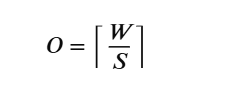

In [7]:
class DepthwiseSeparableConv(layers.Layer):
  # dw ,pw = depth and point wise convolution
  def __init__(self,filters,kernel_size=3,strides=1):
    super().__init__()
    self.dw = layers.DepthwiseConv2D(kernel_size=kernel_size,strides=strides,padding='same')
    self.pw = layers.Conv2D(filters=filters,kernel_size=1,strides=1)

    self.bn = layers.BatchNormalization()


  def call(self,inputs):
    x = self.dw(inputs)
    x = self.pw(x)
    return tf.nn.relu(self.bn(x))





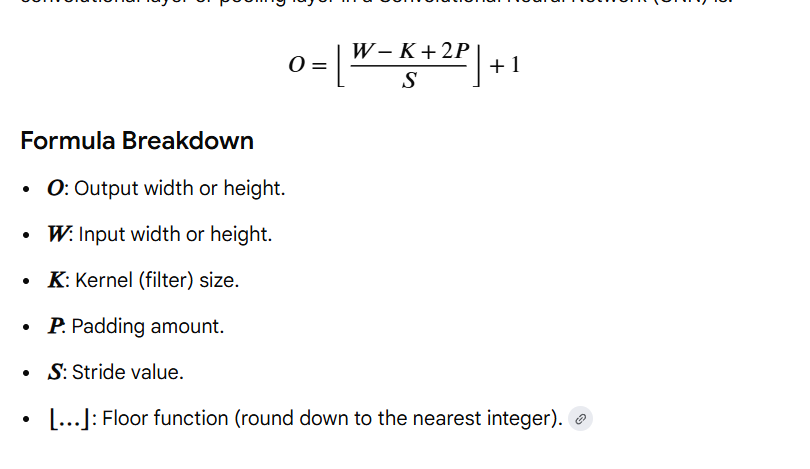

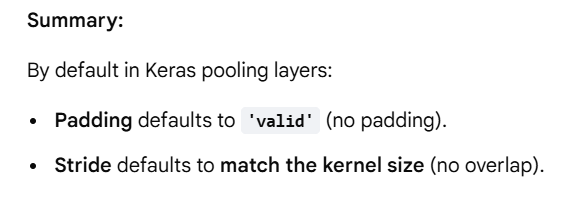

In [50]:
def create_fibonacci_net(input_shape=(224,224,3),num_classes=1):

    inputs= layers.Input(shape=input_shape)




  # block1 (21 filter)
    x= layers.Conv2D(21,3,padding='same')(inputs) #(224, 224, 21)

    x= layers.BatchNormalization()(x)  #(224, 224, 21)

    x= layers.ReLU()(x)

    x= layers.MaxPooling2D(2)(x)  # 112x112x21


    # Block 2 34 filters

    x = layers.Conv2D(34,3,padding='same')(x) # 112x112x34
    x = layers.BatchNormalization()(x) # 112x112x34
    x = layers.ReLU()(x)# 112x112x34
    x2 = x  # 112x112x34
    x= layers.MaxPooling2D(2)(x)  # 56x56x34

    # Block 3  (55 filters)

    x = layers.Conv2D(55,3,padding='same')(x)  # 56x56x55
    x = layers.BatchNormalization()(x) # 56x56x55
    x = layers.ReLU()(x) # 56x56x55
    x3=x

    x= layers.MaxPooling2D(2)(x)  # 28x28x55


    # =================================================
    # pcb1: Block 2 -> Block 4
    # =================================================

    pcb1 = layers.Conv2D(24,3,padding='same')(x2)  # 112x112x24
    pcb1  = Avg2MaxPooling()(pcb1) #w/s  (56×56×24)


    pcb1 = layers.Conv2D(24,3,padding='same')(pcb1) #(56×56×24)
    pcb1  = Avg2MaxPooling()(pcb1) #(28×28×24)


    # =================================================
    # Block 4
    # =================================================

    x = layers.Conv2D(89,3,padding='same')(x)  # 28x28x89
    x= layers.BatchNormalization()(x) # 28x28x89
    x= layers.ReLU()(x) # 28x28x89

    x=layers.MaxPooling2D(2)(x) #  # 14x14x89


    pcb1 = layers.Resizing(14,14)(pcb1)

    x= layers.Concatenate()([x,pcb1]) #14×14×113



    # =================================================
    # pcb2 : Block3 -> Block5
    # =================================================


    pcb2 =layers.Conv2D(24,3,padding='same')(x3) # # 56x56x24

    pcb2 = Avg2MaxPooling()(pcb2)#  (28x28x24)


    pcb2 =layers.Conv2D(24,3,padding='same')(pcb2) #  (28x28x24)
    pcb2 = Avg2MaxPooling()(pcb2)# (14,14,24)


    # =================================================
    # Block 5
    # =================================================

    x = layers.Conv2D(144,3,padding='same')(x)  # 14x14x114

    x= layers.BatchNormalization()(x) #  14x14x114

    x= layers.ReLU()(x) # 14x14x114

    x=layers.MaxPooling2D(2)(x) # 7x7x144


    pcb2 = layers.Resizing(7,7)(pcb2)

    x = layers.Concatenate()([x,pcb2]) #(7x7x168)


# -------- Block 6 (233 filters, DWSC) --------


    x =layers.Conv2D(233,3,padding='same')(x) # 7x7x233

    x= layers.BatchNormalization()(x) # 7x7x233

    x= layers.ReLU()(x) # 7x7x233


    x  = DepthwiseSeparableConv(233)(x)

# ----------------------------------------------

# -------- Block 7 (377 filters, DWSC) --------



    x =layers.Conv2D(377,3,padding='same')(x) # 7x7x377

    x= layers.BatchNormalization()(x) #7x7x 377

    x= layers.ReLU()(x) # 7x7x377


    x  = DepthwiseSeparableConv(377)(x)  # 7x7x377


    x = layers.GlobalAveragePooling2D()(x)

    #output

    outputs = layers.Dense(units=1,activation='sigmoid')(x)

    return Model(inputs,outputs)





In [51]:
model = create_fibonacci_net(num_classes=1)

In [52]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        588 │ input_layer[0][0] │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │         84 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      6,460 │ max_pooling2d[0]… │
│                     │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        136 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     16,885 │ max_pooling2d_1[… │
│                     │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        220 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      7,368 │ re_lu_1[0][0]     │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     44,144 │ max_pooling2d_2[… │
│                     │ 89)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg2_max_pooling    │ (None, 56, 56,    │         96 │ conv2d_3[0][0]    │
│ (Avg2MaxPooling)    │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        356 │ conv2d_5[0][0]  

 Total params: 1,597,974 (6.10 MB)

 Trainable params: 1,594,656 (6.08 MB)

 Non-trainable params: 3,318 (12.96 KB)

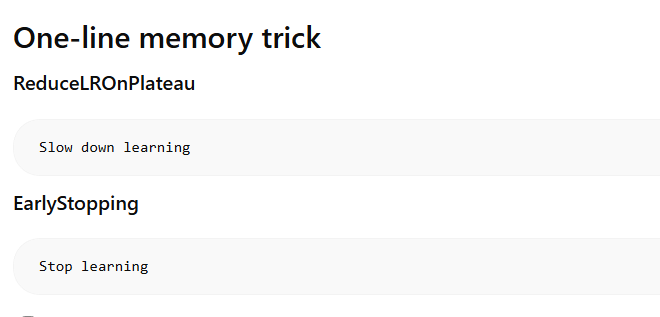

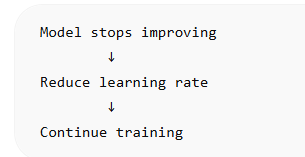

In [53]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = ['accuracy',tf.keras.metrics.AUC()]
)



In [ ]:
early_stop= EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3, verbose=1)

In [55]:
history1 = model.fit(
    train_gen_new,
    validation_data = valid_gen_new,
    epochs = 40,
    batch_size= 16,
    callbacks = [early_stop,reduce_lr]
)


Epoch 1/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 48s 223ms/step - accuracy: 0.6572 - auc: 0.7223 - loss: 0.6109 - val_accuracy: 0.4987 - val_auc: 0.5054 - val_loss: 0.6936 - learning_rate: 1.0000e-04
Epoch 2/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 42s 219ms/step - accuracy: 0.7405 - auc: 0.8274 - loss: 0.5119 - val_accuracy: 0.4987 - val_auc: 0.5885 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 3/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.8150 - auc: 0.8996 - loss: 0.4069 - val_accuracy: 0.6457 - val_auc: 0.7368 - val_loss: 0.6483 - learning_rate: 1.0000e-04
Epoch 4/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - accuracy: 0.8671 - auc: 0.9455 - loss: 0.3052 - val_accuracy: 0.7927 - val_auc: 0.8899 - val_loss: 0.4309 - learning_rate: 1.0000e-04
Epoch 5/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - accuracy: 0.9262 - auc: 0.9782 - loss: 0.1957 - val_accuracy: 0.5354 - val_auc: 0.7633 - val_loss: 2.1394 - learning_rate: 1.0000e-04
Epoch 6/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 21

In [56]:
results = model.evaluate(test_gen_new)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test AUC:", results[2])

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8215 - auc: 0.9149 - loss: 0.3965
Test Loss: 0.3964967429637909
Test Accuracy: 0.8215222954750061
Test AUC: 0.9149489998817444


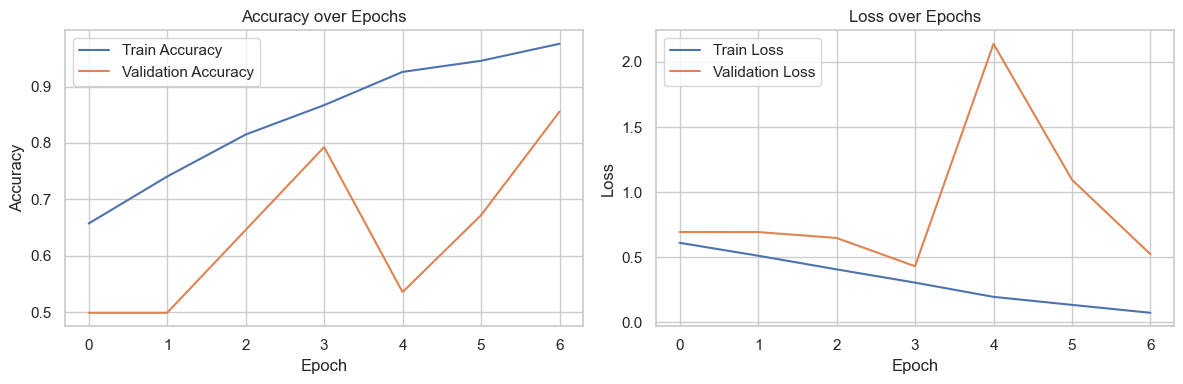

In [57]:
def plot_history(history1):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'], label='Train Accuracy')
    plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history1.history['loss'], label='Train Loss')
    plt.plot(history1.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history1)

In [71]:
test_gen_new.reset()

y_true = test_gen_new.classes
y_pred_probs = model.predict(test_gen_new,steps=len(test_gen_new))
y_pred = (y_pred_probs>0.5).astype(int)



24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [79]:
def plot_confusion_matrix(y_true,y_pred):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',  
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive']
                )
    
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    

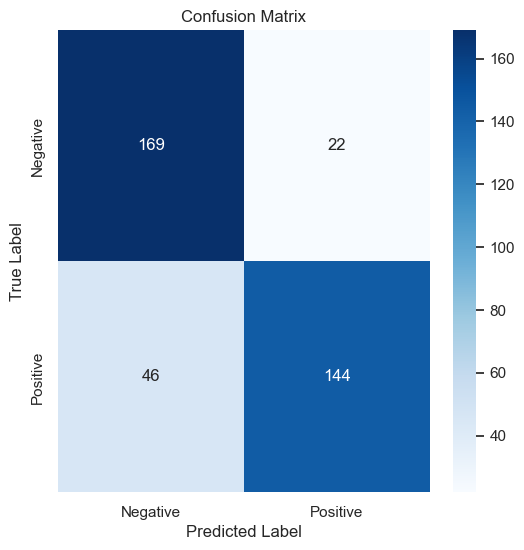

In [80]:
plot_confusion_matrix(y_true,y_pred)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


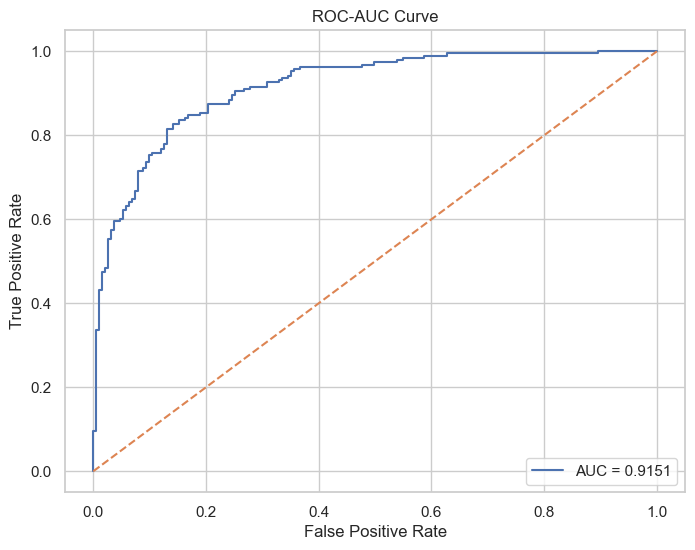

In [81]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_pred_probs = model.predict(test_gen_new).ravel()

# True labels
y_true = test_gen_new.classes

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

About 91.5% of the time, your model gives higher cancer probability to malignant images than benign images

In [ ]:
# import os
# os.chdir('..')

# file_path ="model artifacts/thyroid_cancer_model.h5"

# size_mb = os.path.getsize(file_path) / (1024 * 1024)

# print(f"Size: {size_mb:.2f} MB")

Size: 18.48 MB


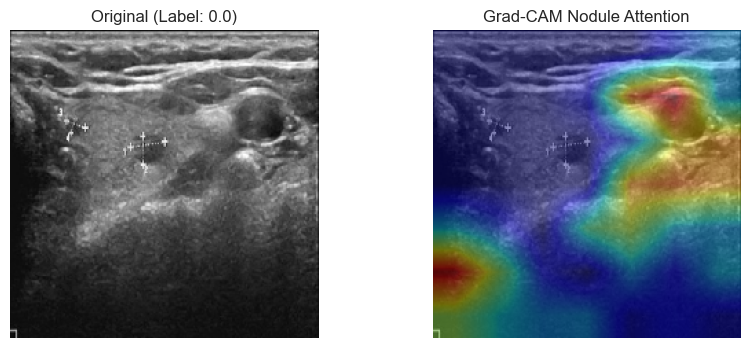

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            # For binary classification with sigmoid, we look at the single output value
            class_channel = preds[:, 0]
        else:
            class_channel = preds[:, pred_index]

    # This is the gradient of the output node with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()





# Select a sample from the test generator
# ImageDataGenerator returns (x, y) batches
test_gen_new.reset()
sample_batch_x, sample_batch_y = next(test_gen_new)
img_sample = sample_batch_x[0:1] # Take first image of batch
label_sample = sample_batch_y[0]

# Find the last layer of the DWSC tail
# Your FibonacciNet uses DepthwiseSeparableConv layers
last_conv_name = None
for layer in reversed(model.layers):
    if isinstance(layer, DepthwiseSeparableConv) or "depthwise_separable_conv" in layer.name:
        last_conv_name = layer.name
        break

if last_conv_name:
    heatmap = make_gradcam_heatmap(img_sample, model, last_conv_name)

    # Display result
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_sample[0])
    plt.title(f"Original (Label: {label_sample})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_sample[0])
    # Resize heatmap to match image size
    img_size = [224,224]
    resized_heatmap = cv2.resize(heatmap, (img_size[0], img_size[1]))
    plt.imshow(resized_heatmap, alpha=0.4, cmap='jet')
    plt.title("Grad-CAM Nodule Attention")
    plt.axis('off')
    plt.show()
else:
    print("Could not find a valid convolutional layer for Grad-CAM.")

In [3]:
import os
os.chdir('..')


In [4]:

import tensorflow as tf
from huggingface_hub import hf_hub_download, upload_file

# Import shared utils
from utils.config import REPO_ID, MODEL_FILENAME
from utils.logger import get_logger
from utils.model_architecture import Avg2MaxPooling, DepthwiseSeparableConv
from utils.processing import preprocess_image
from utils.gradcam import make_gradcam_heatmap, save_and_display_gradcam
from utils.report_generator import generate_docx_report


In [ ]:
# MODEL = None 
# def load_model():
#     """Loads model from Hugging Face Hub"""
#     global MODEL
#     if MODEL is None:
        
            
#         model_path = hf_hub_download(repo_id=REPO_ID, filename=MODEL_FILENAME)
#         custom_objects = {
#             "Avg2MaxPooling": Avg2MaxPooling, 
#             "DepthwiseSeparableConv": DepthwiseSeparableConv
#         }
#         MODEL = tf.keras.models.load_model(model_path, custom_objects=custom_objects, compile=False)
        
        
            

In [ ]:
# load_model()



c:\Users\DELL\Desktop\thyroid\.venv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'avg2_max_pooling', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\DELL\Desktop\thyroid\.venv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'avg2_max_pooling_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\DELL\Desktop\thyroid\.venv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was call

In [ ]:
# from tensorflow.keras.preprocessing import image
# import numpy as np

# img = image.load_img(
#     r'Thyroid Data\0\0001.jpg',
#     target_size=(224, 224)   # model ke input size ke hisab se
# )

# img = image.img_to_array(img)
# img = np.expand_dims(img, axis=0)

# preds = MODEL.predict(img)

# print(preds.shape)
# print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
(1, 1)
[[0.]]


In [ ]:
# print(MODEL.input_shape)
# print(MODEL.output_shape)

(None, 224, 224, 3)
(None, 1)


In [ ]:
# print(MODEL)

None


# Grad-CAM Flow (Very Short & Simple)

---

# Goal of Grad-CAM

Shows:

```text id="g1"
Which image regions the CNN focused on
```

for prediction.

---

# Complete Flow

```text id="g2"
Input Image
↓
CNN extracts features
↓
Last Conv Layer Feature Maps
↓
Prediction
↓
Compute gradients
↓
Measure important channels
↓
Create heatmap
↓
Overlay on image
```

---

# Function-by-Function

---

# 1. `grad_model`

```python id="g3"
grad_model = tf.keras.models.Model(...)
```

Creates temporary model.

Outputs:

* last conv layer
* final prediction

---

# 2. `GradientTape`

```python id="g4"
with tf.GradientTape() as tape:
```

Records operations.

Needed to compute gradients.

---

# 3. Forward Pass

```python id="g5"
last_conv_layer_output, preds = grad_model(img_array)
```

Model predicts image.

Outputs:

* feature maps
* prediction score

---

# 4. Select Prediction Score

```python id="g6"
class_channel = preds[:,0]
```

Chooses class to explain.

For your model:

```text id="g7"
malignant probability
```

---

# 5. Compute Gradients

```python id="g8"
grads = tape.gradient(...)
```

Finds:

```text id="g9"
Which feature maps affected prediction most
```

---

# 6. Average Gradients

```python id="g10"
pooled_grads = tf.reduce_mean(...)
```

Gets importance score for each channel.

---

# 7. Weight Feature Maps

```python id="g11"
heatmap = feature_maps × importance
```

Important channels contribute more.

---

# 8. Normalize Heatmap

```python id="g12"
heatmap = heatmap / max
```

Scales between:

0 \rightarrow 1

---

# 9. Resize Heatmap

```python id="g13"
cv2.resize(...)
```

Matches original image size.

---

# 10. Overlay Heatmap

```python id="g14"
plt.imshow(... alpha=0.4)
```

Places attention map over ultrasound.

---

# Color Meaning

| Color      | Meaning          |
| ---------- | ---------------- |
| Red/Yellow | Strong attention |
| Blue       | Weak attention   |

---

# Final Meaning

Grad-CAM answers:

```text id="g15"
WHY did the model predict cancer?
```

by highlighting suspicious thyroid regions.


In [ ]:
model.save('thyroid_cancer_model.keras')

In [ ]:
model.save('thyroid_cancer_model.h5')